In [5]:
#Import basic libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
sb.set()

In [6]:
cardio_clean = pd.read_csv("cardio_clean_new.csv")

In [7]:
#  checking what the cleaned dataset looks like


print("Shape:", cardio_clean.shape)

print("\nColumns:")
print(cardio_clean.columns.tolist())

# quick preview
cardio_clean.head()

Shape: (65886, 18)

Columns:
['id', 'age', 'gender', 'height', 'weight', 'bp_systolic', 'bp_diastolic', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio', 'bmi', 'age_years', 'age_cat', 'age_cat_int', 'pulse_pressure']


,id,age,gender,height,weight,bp_systolic,bp_diastolic,cholesterol,gluc,smoke,alco,active,cardio,bmi,age_years,age_cat,age_cat_int,pulse_pressure
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0,21.97,50,45-54,2,30
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1,34.93,55,45-54,2,50
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1,23.51,51,45-54,2,60
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1,28.71,48,45-54,2,50
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0,23.01,47,45-54,2,40


cardio
0    33364
1    32522
Name: count, dtype: int64


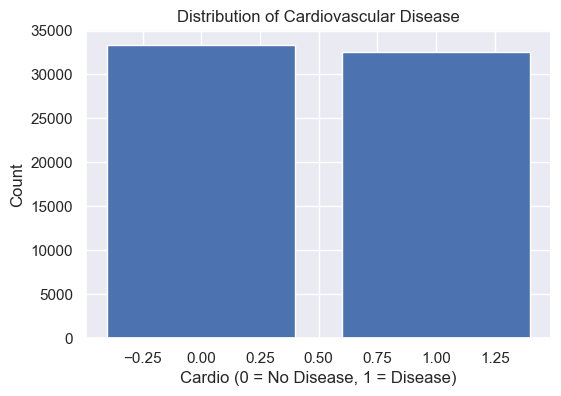

In [13]:
# checking to see if the dataset is balanced or not
# if it is too skewed, later analysis might be misleading

cardio_counts = cardio_clean["cardio"].value_counts().sort_index()
print(cardio_counts)

plt.figure(figsize=(6,4))
plt.bar(cardio_counts.index, cardio_counts.values)

plt.title("Distribution of Cardiovascular Disease")
plt.xlabel("Cardio (0 = No Disease, 1 = Disease)")
plt.ylabel("Count")

plt.show()

In [9]:
# checking how relationships with cardio change across different age groups
# idea: maybe some factors matter more depending on age

for grp in sorted(cardio_clean["age_cat"].dropna().unique()):
    
    # filter dataset to only this specific age group
    subset = cardio_clean[cardio_clean["age_cat"] == grp]
    
    # compute correlation with cardio for this group
    # dropping 'cardio' itself because it's always 1.0
    corr_vals = subset.corr(numeric_only=True)["cardio"].drop("cardio")
    
    # print results so we can compare across age groups
    print(f"\nAge Group: {grp}")
    
    # show top 5 strongest relationships for easier reading
    print(corr_vals.sort_values(ascending=False).head(5))


Age Group: 25-34
id       NaN
age      NaN
gender   NaN
height   NaN
weight   NaN
Name: cardio, dtype: float64

Age Group: 35-44
bp_systolic       0.503214
bp_diastolic      0.407809
pulse_pressure    0.375318
cholesterol       0.241692
weight            0.234072
Name: cardio, dtype: float64

Age Group: 45-54
bp_systolic       0.437898
bp_diastolic      0.349638
pulse_pressure    0.327899
cholesterol       0.208985
bmi               0.194593
Name: cardio, dtype: float64

Age Group: 55-64
bp_systolic       0.328598
pulse_pressure    0.263498
bp_diastolic      0.247996
cholesterol       0.174168
bmi               0.139438
Name: cardio, dtype: float64


In [14]:
# checking which variables are most related to cardio
# this helps identify the "important factors" for our question statement

cardio_corr = cardio_clean.corr(numeric_only=True)["cardio"].sort_values(ascending=False)
print(cardio_corr)

cardio            1.000000
bp_systolic       0.429075
bp_diastolic      0.340836
pulse_pressure    0.330680
age               0.236824
age_years         0.236652
cholesterol       0.220338
age_cat_int       0.215592
bmi               0.192094
weight            0.183538
gluc              0.087358
gender            0.009394
id                0.004670
alco             -0.008044
height           -0.008512
smoke            -0.016078
active           -0.038653
Name: cardio, dtype: float64


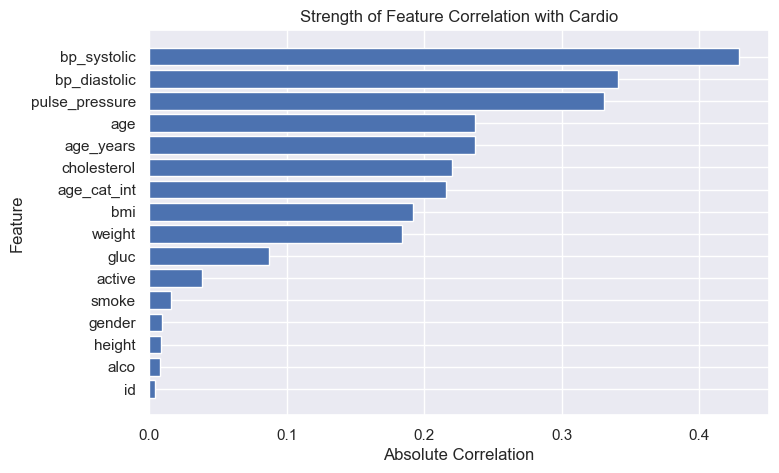

In [15]:
# plotting correlation values to make it easier to compare
# using absolute value since both + and - matter for strength

top_corr = cardio_clean.corr(numeric_only=True)["cardio"].drop("cardio").abs().sort_values(ascending=False)

plt.figure(figsize=(8,5))
plt.barh(top_corr.index, top_corr.values)

plt.title("Strength of Feature Correlation with Cardio")
plt.xlabel("Absolute Correlation")
plt.ylabel("Feature")

plt.gca().invert_yaxis()
plt.show()

In [16]:
# if cleaning cells weren't run yet, this makes sure
# the columns needed for my EDA are available

# rename BP columns to cleaned names if needed
if "ap_hi" in cardio_clean.columns and "bp_systolic" not in cardio_clean.columns:
    cardio_clean = cardio_clean.rename(columns={"ap_hi": "bp_systolic"})

if "ap_lo" in cardio_clean.columns and "bp_diastolic" not in cardio_clean.columns:
    cardio_clean = cardio_clean.rename(columns={"ap_lo": "bp_diastolic"})

# create bmi only if it's not already there
if "bmi" not in cardio_clean.columns:
    cardio_clean["bmi"] = cardio_clean["weight"] / ((cardio_clean["height"] / 100) ** 2)
    cardio_clean["bmi"] = cardio_clean["bmi"].round(2)

# create pulse pressure only if it's not already there
if "pulse_pressure" not in cardio_clean.columns:
    cardio_clean["pulse_pressure"] = cardio_clean["bp_systolic"] - cardio_clean["bp_diastolic"]

# just checking
print(cardio_clean.columns.tolist())
cardio_clean.head()

['id', 'age', 'gender', 'height', 'weight', 'bp_systolic', 'bp_diastolic', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio', 'bmi', 'age_years', 'age_cat', 'age_cat_int', 'pulse_pressure']


,id,age,gender,height,weight,bp_systolic,bp_diastolic,cholesterol,gluc,smoke,alco,active,cardio,bmi,age_years,age_cat,age_cat_int,pulse_pressure
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0,21.97,50,45-54,2,30
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1,34.93,55,45-54,2,50
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1,23.51,51,45-54,2,60
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1,28.71,48,45-54,2,50
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0,23.01,47,45-54,2,40


In [17]:
# remove unrealistic values
cardio_clean = cardio_clean[
    (cardio_clean["bp_systolic"].between(80, 250)) &
    (cardio_clean["bp_diastolic"].between(40, 150))
]

# ensure logical relationship
cardio_clean = cardio_clean[
    cardio_clean["bp_systolic"] > cardio_clean["bp_diastolic"]
]

<Figure size 600x400 with 0 Axes>

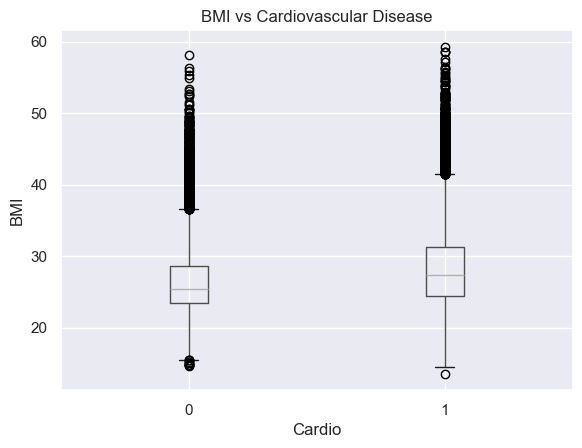

In [18]:
# bmi already available now
# just checking if the cardio group tends to have higher bmi

plt.figure(figsize=(6,4))
cardio_clean.boxplot(column="bmi", by="cardio")

plt.title("BMI vs Cardiovascular Disease")
plt.suptitle("")
plt.xlabel("Cardio")
plt.ylabel("BMI")

plt.show()

Shape after BP filtering: (65855, 18)
        bp_systolic  bp_diastolic  pulse_pressure
count  65855.000000  65855.000000    65855.000000
mean     126.604328     81.319444       45.284883
std       16.319274      9.240258       11.442449
min       90.000000     55.000000        5.000000
25%      120.000000     80.000000       40.000000
50%      120.000000     80.000000       40.000000
75%      140.000000     90.000000       50.000000
max      200.000000    150.000000      135.000000


<Figure size 600x400 with 0 Axes>

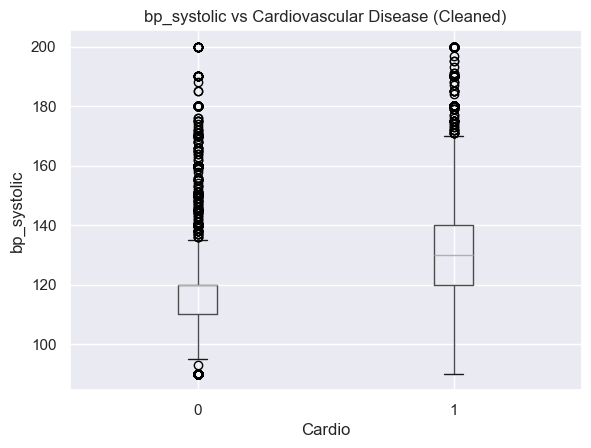

<Figure size 600x400 with 0 Axes>

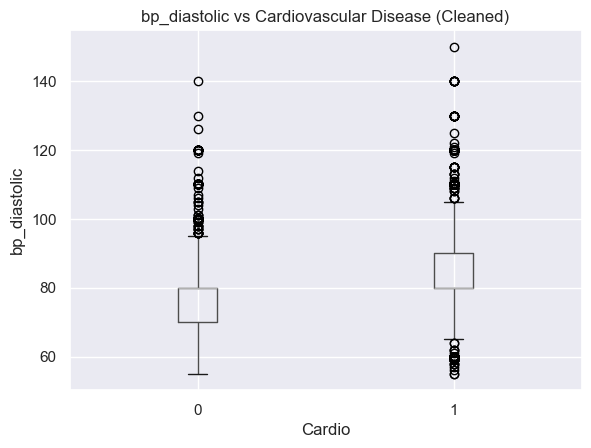

<Figure size 600x400 with 0 Axes>

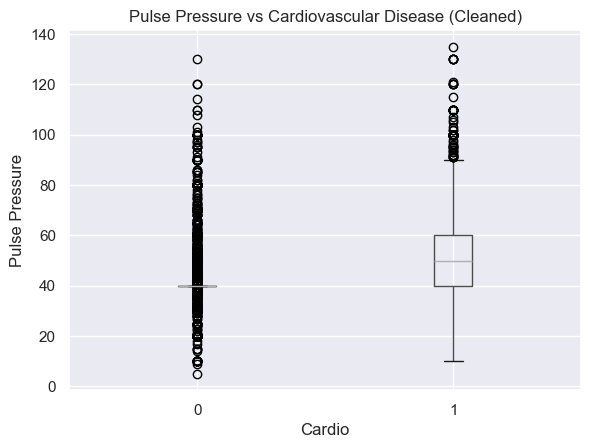

In [19]:
# cleaning BP data before the blood pressure analysis
# this makes sure the later plots use realistic values

bp_filtered = cardio_clean[
    (cardio_clean["bp_systolic"].between(80, 250)) &
    (cardio_clean["bp_diastolic"].between(40, 150)) &
    (cardio_clean["bp_systolic"] > cardio_clean["bp_diastolic"])
].copy()

# recompute pulse pressure using the cleaned BP values
bp_filtered["pulse_pressure"] = (
    bp_filtered["bp_systolic"] - bp_filtered["bp_diastolic"]
)

# quick check
print("Shape after BP filtering:", bp_filtered.shape)
print(bp_filtered[["bp_systolic", "bp_diastolic", "pulse_pressure"]].describe())

# comparing systolic and diastolic BP across cardio groups
for col in ["bp_systolic", "bp_diastolic"]:
    plt.figure(figsize=(6,4))
    bp_filtered.boxplot(column=col, by="cardio")

    plt.title(f"{col} vs Cardiovascular Disease (Cleaned)")
    plt.suptitle("")
    plt.xlabel("Cardio")
    plt.ylabel(col)

    plt.show()

# checking pulse pressure after cleaning
plt.figure(figsize=(6,4))
bp_filtered.boxplot(column="pulse_pressure", by="cardio")

plt.title("Pulse Pressure vs Cardiovascular Disease (Cleaned)")
plt.suptitle("")
plt.xlabel("Cardio")
plt.ylabel("Pulse Pressure")

plt.show()

<Figure size 600x400 with 0 Axes>

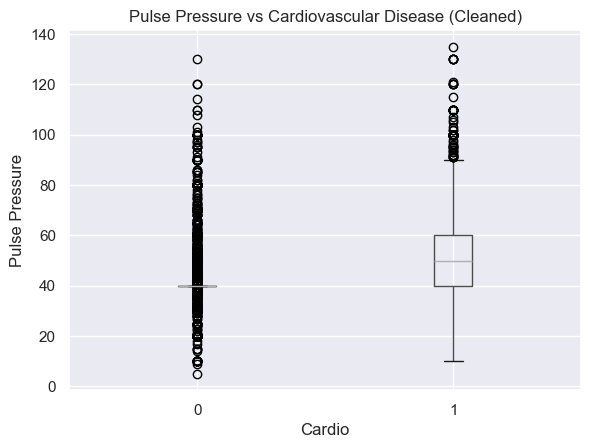

In [20]:
# cleaning BP data + recomputing pulse pressure + plotting

bp_filtered = cardio_clean[
    (cardio_clean["bp_systolic"].between(80, 250)) &
    (cardio_clean["bp_diastolic"].between(40, 150)) &
    (cardio_clean["bp_systolic"] > cardio_clean["bp_diastolic"])
].copy()

# recompute pulse pressure using cleaned data
bp_filtered["pulse_pressure"] = (
    bp_filtered["bp_systolic"] - bp_filtered["bp_diastolic"]
)

# plot
plt.figure(figsize=(6,4))
bp_filtered.boxplot(column="pulse_pressure", by="cardio")

plt.title("Pulse Pressure vs Cardiovascular Disease (Cleaned)")
plt.suptitle("")
plt.xlabel("Cardio")
plt.ylabel("Pulse Pressure")

plt.show()

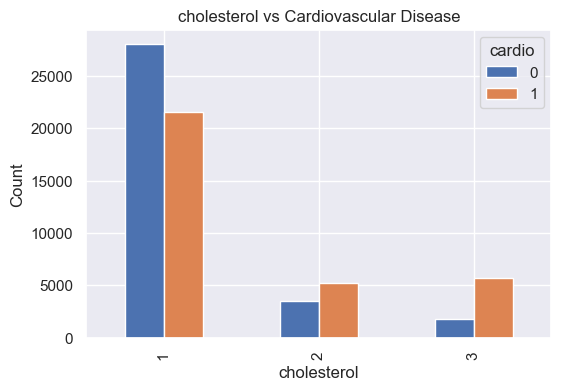

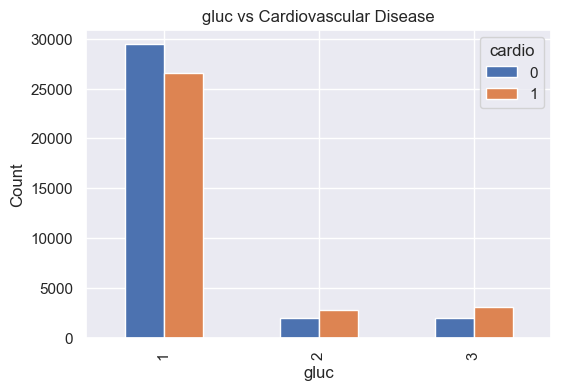

In [21]:
# checking how cardio cases are spread across cholesterol and glucose levels

for col in ["cholesterol", "gluc"]:
    grouped = cardio_clean.groupby([col, "cardio"]).size().unstack(fill_value=0)

    grouped.plot(kind="bar", figsize=(6,4))
    plt.title(f"{col} vs Cardiovascular Disease")
    plt.xlabel(col)
    plt.ylabel("Count")

    plt.show()

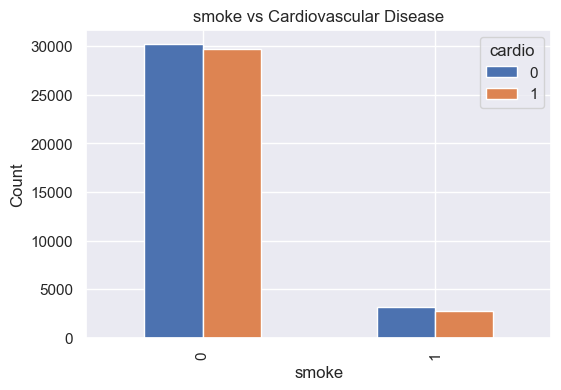

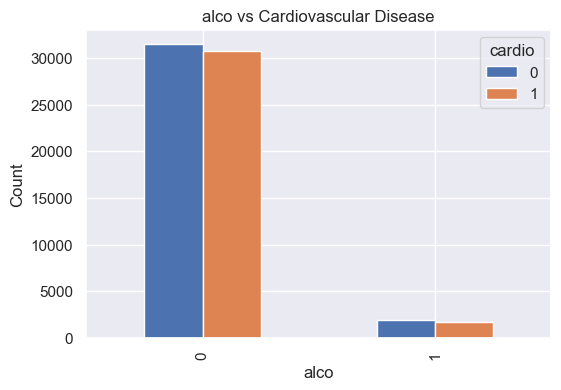

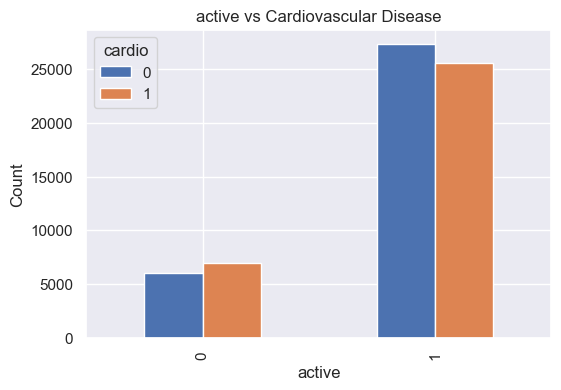

In [22]:
# checking smoking, alcohol and physical activity
# these are lifestyle factors so pattern may be weaker

for col in ["smoke", "alco", "active"]:
    grouped = cardio_clean.groupby([col, "cardio"]).size().unstack(fill_value=0)

    grouped.plot(kind="bar", figsize=(6,4))
    plt.title(f"{col} vs Cardiovascular Disease")
    plt.xlabel(col)
    plt.ylabel("Count")

    plt.show()

In [23]:
# counts can be misleading if one category has more people
# so this checks the actual disease rate within each group

for col in ["cholesterol", "gluc", "smoke", "alco", "active"]:
    print(f"\nCardio rate by {col}:")
    print(cardio_clean.groupby(col)["cardio"].mean().round(3))


Cardio rate by cholesterol:
cholesterol
1    0.435
2    0.596
3    0.761
Name: cardio, dtype: float64

Cardio rate by gluc:
gluc
1    0.475
2    0.587
3    0.613
Name: cardio, dtype: float64

Cardio rate by smoke:
smoke
0    0.496
1    0.468
Name: cardio, dtype: float64

Cardio rate by alco:
alco
0    0.494
1    0.476
Name: cardio, dtype: float64

Cardio rate by active:
active
0    0.533
1    0.484
Name: cardio, dtype: float64


In [24]:
# checking which numerical variables are most related to cardio overall

cardio_corr = cardio_clean.corr(numeric_only=True)["cardio"].sort_values(ascending=False)
print(cardio_corr)

cardio            1.000000
bp_systolic       0.430281
bp_diastolic      0.341787
pulse_pressure    0.337661
age               0.236937
age_years         0.236764
cholesterol       0.220397
age_cat_int       0.215709
bmi               0.192063
weight            0.183445
gluc              0.087282
gender            0.009233
id                0.004766
alco             -0.008596
height           -0.008640
smoke            -0.016103
active           -0.038738
Name: cardio, dtype: float64


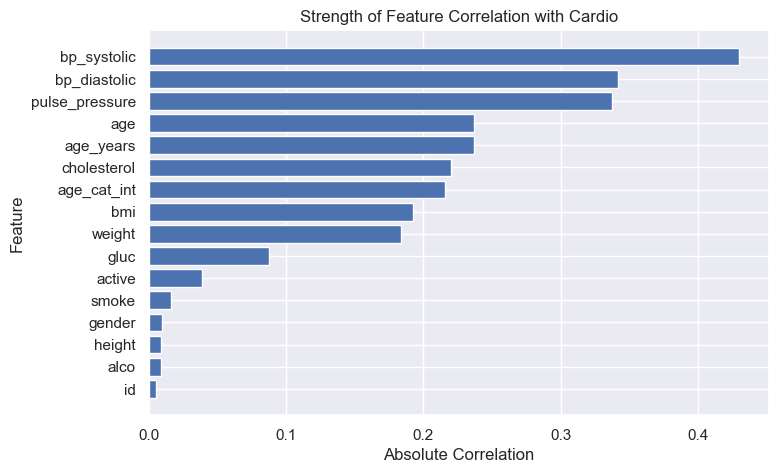

In [25]:
# easier to compare the strength visually
# using absolute value because strength matters more than sign here

corr_strength = cardio_clean.corr(numeric_only=True)["cardio"].drop("cardio").abs().sort_values(ascending=False)

plt.figure(figsize=(8,5))
plt.barh(corr_strength.index, corr_strength.values)

plt.title("Strength of Feature Correlation with Cardio")
plt.xlabel("Absolute Correlation")
plt.ylabel("Feature")

plt.gca().invert_yaxis()
plt.show()

In [26]:
# short wrap-up before handing over to ML part

print("""
EDA Summary

- Blood pressure, BMI and pulse pressure show clearer differences between cardio groups.
- Cholesterol and glucose are also associated with higher cardio rates.
- Lifestyle factors such as smoking and alcohol show weaker patterns compared to clinical indicators.
- Overall, clinical indicators seem more strongly associated with cardiovascular disease.
""")


EDA Summary

- Blood pressure, BMI and pulse pressure show clearer differences between cardio groups.
- Cholesterol and glucose are also associated with higher cardio rates.
- Lifestyle factors such as smoking and alcohol show weaker patterns compared to clinical indicators.
- Overall, clinical indicators seem more strongly associated with cardiovascular disease.

